# splitQP

This notebook solves a family of quadratic programs that share a fixed `P` and `A`
while `q`, `l`, and `u` vary. `solve_batch` treats the members as independent;
`solve_sequence` follows the ordered family with warm starts. Both reuse the single
Cholesky factorization formed when the `Solver` is constructed.

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import splitqp

In [2]:
# One fixed (P, A); member i tracks a moving centre x(t_i), so adjacent members
# have nearby optima (good for warm starts).
rng = np.random.default_rng(0)
n, m, B = 8, 12, 24
M = rng.normal(size=(n, n))
P = M @ M.T + n * np.eye(n)                    # fixed, symmetric positive definite
A = rng.normal(size=(m, n)); A /= np.linalg.norm(A, axis=1, keepdims=True)

x0, dx = rng.normal(size=n), rng.normal(size=n)
width = rng.uniform(0.3, 0.8, size=m)
t = np.linspace(0.0, 1.0, B)                   # the ordered family parameter
qs = np.zeros((B, n)); ls = np.zeros((B, m)); us = np.zeros((B, m))
for i, ti in enumerate(t):
    xc = x0 + ti * dx
    c = A @ xc
    ls[i], us[i] = c - width, c + width
    qs[i] = -(P @ xc)

print(f"variables:      {n}")
print(f"constraints:    {m}")
print(f"family members: {B}")

variables:      8
constraints:    12
family members: 24


In [3]:
solver = splitqp.Solver(P, A)                        # the one factorization
scalar = solver.solve(qs[0], ls[0], us[0])           # one member
batch = solver.solve_batch(qs, ls, us)               # independent members
seq = solver.solve_sequence(qs, ls, us)              # ordered, warm-started members

xb, xq = np.asarray(batch.x), np.asarray(seq.x)
b_solved = int(np.sum(np.asarray(batch.status) == "solved"))
q_solved = int(np.sum(np.asarray(seq.status) == "solved"))

print(f"scalar status:          {scalar.status}")
print(f"batch solved:           {b_solved}/{B}")
print(f"sequence solved:        {q_solved}/{B}")
print(f"factorizations:         {solver.factorizations}")
print(f"max scalar-vs-batch:    {np.max(np.abs(np.asarray(scalar.x) - xb[0])):.2e}")
print(f"max batch-vs-sequence:  {np.max(np.abs(xb - xq)):.2e}")
# batch and sequence stop at a relative 1e-6 residual from different warm starts,
# so they agree to the solve tolerance rather than bit-for-bit.  This is not an error.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


scalar status:          solved
batch solved:           24/24
sequence solved:        24/24
factorizations:         1
max scalar-vs-batch:    1.39e-17
max batch-vs-sequence:  4.00e-06


In [4]:
# The same member solved under a growing iteration budget, so the ADMM residuals are
# visible on the way down rather than only at the stop.  Every row reuses the one
# factorization made when `solver` was constructed.
print(f"{'max_iter':>9} {'r_primal':>10} {'r_dual':>10} {'objective':>13}  status")
for budget in (1, 2, 4, 8, 16, 32, 64):
    r = solver.solve(qs[0], ls[0], us[0], max_iter=budget)
    print(f"{budget:>9} {float(r.r_primal):>10.2e} {float(r.r_dual):>10.2e}"
          f" {float(r.objective):>13.6f}  {r.status}")
print(f"factorizations after the sweep: {solver.factorizations}")

 max_iter   r_primal     r_dual     objective  status
        1   4.00e-01   1.27e+01    -24.921073  max_iter
        2   6.41e-01   7.46e+00    -33.082148  max_iter
        4   2.31e-01   2.62e+00    -36.912367  max_iter
        8   2.99e-02   3.26e-01    -37.455548  max_iter
       16   5.02e-04   5.14e-03    -37.464433  max_iter
       32   1.82e-06   1.76e-05    -37.464435  solved
       64   1.82e-06   1.76e-05    -37.464435  solved
factorizations after the sweep: 1


In [5]:
# A few representative members (first, middle, last), not the whole family, with the
# per-member diagnostics the sequence carries back.
seq_iters = np.asarray(seq.iterations)
seq_obj, seq_rp, seq_rd = (np.asarray(w) for w in (seq.objective, seq.r_primal, seq.r_dual))
seq_status = np.asarray(seq.status)
print(f"{'member':>6} {'parameter':>10} {'x[0]':>9} {'x[1]':>9} {'iters':>6}"
      f" {'objective':>12} {'r_primal':>10} {'r_dual':>10}  status")
for i in (0, B // 2, B - 1):
    print(f"{i:>6} {t[i]:>10.3f} {xq[i, 0]:>9.4f} {xq[i, 1]:>9.4f} {int(seq_iters[i]):>6}"
          f" {seq_obj[i]:>12.6f} {seq_rp[i]:>10.2e} {seq_rd[i]:>10.2e}  {seq_status[i]}")

member  parameter      x[0]      x[1]  iters    objective   r_primal     r_dual  status
     0      0.000    0.5131   -0.2976     27   -37.464435   1.82e-06   1.76e-05  solved
    12      0.522    1.3725    0.1811     20   -69.520498   8.88e-16   2.89e-05  solved
    23      1.000    2.1604    0.6199     20  -119.463577   4.44e-16   2.89e-05  solved


In [6]:
batch_iters = np.asarray(batch.iterations)
print("sequence iterations:  "
      f"min {int(seq_iters.min())}, median {int(np.median(seq_iters))}, max {int(seq_iters.max())}")
print("batch iterations:     "
      f"min {int(batch_iters.min())}, median {int(np.median(batch_iters))}, max {int(batch_iters.max())}")

sequence iterations:  min 20, median 20, max 27
batch iterations:     min 27, median 27, max 28


`solve_batch` members are independent; `solve_sequence` members are ordered and
warm-started, which is why the sequence usually takes fewer total iterations. Both
reuse the same construction-time factorization. For optional local timing
comparisons, see `bench.py`.

## Preconditioning: the same QP in a better metric

ADMM is sensitive not only to the objective and feasible set, but also to
the coordinates used to represent them. The experiment below writes one QP
in two equivalent constraint coordinate systems. A scalar penalty cannot
balance both directions at once; row equilibration, or equivalently a
diagonal ADMM penalty, makes the augmented geometry nearly isotropic.

Three separate things are called preconditioning; only the first two act here.

- **Constraint equilibration** rescales the rows of $A$ and the box with them.
  It changes the *representation* of the problem. The rescaling below is built
  by hand for one two-dimensional example; it is not Ruiz equilibration.
- **A diagonal penalty** $R = \operatorname{diag}(\rho)$ changes the *metric* of
  the outer ADMM iteration. Writing $R = F^\top F$ turns $\tfrac12 r^\top R r$
  into $\tfrac12\lVert Fr\rVert_2^2$, so the two moves are the same one.
- **Linear-solver preconditioning** only changes the cost of the *inner* linear
  system. splitQP reuses one direct Cholesky factor, so it plays no part here.

In [7]:
# One physical QP: minimise 0.5*||x - c||^2 subject to -1 <= Brot x <= 1, with Brot
# a rotation.  Because Brot is orthogonal, w = Brot x is the canonical constraint
# coordinate and the exact solution is a clip of the unconstrained target.
theta = np.deg2rad(30.0)
Brot = np.array([[np.cos(theta), np.sin(theta)],
                 [-np.sin(theta), np.cos(theta)]])
c = np.array([1.0, 3.0])
P_2d, q_2d = np.eye(2), -c                     # the omitted 0.5*||c||^2 moves no optimum
x_star = Brot.T @ np.clip(Brot @ c, -1.0, 1.0)

# The same feasible set, written badly: rows scaled by S, bounds scaled with them.
S = np.diag([10.0, 0.1])
A_raw, l_raw, u_raw = S @ Brot, -np.array([10.0, 0.1]), np.array([10.0, 0.1])

# Equilibrated rows: E undoes S, so the constraint coordinates become w itself.
E = np.linalg.inv(S)
A_eq, l_eq, u_eq = E @ A_raw, E @ l_raw, E @ u_raw
rho_diag = np.diag(E.T @ E)                    # the same E as a diagonal ADMM penalty

assert np.allclose(A_eq, Brot) and np.allclose(l_eq, -1.0) and np.allclose(u_eq, 1.0)
assert np.allclose(A_eq.T @ A_eq, np.eye(2))                            # isotropic
assert np.allclose(A_raw.T @ (rho_diag[:, None] * A_raw), np.eye(2))    # isotropic too

raw_pen = np.linalg.eigvalsh(A_raw.T @ A_raw)
print(f"raw penalty A'A eigenvalues:  {raw_pen[0]:.4g} and {raw_pen[1]:.4g} "
      f"(ratio {raw_pen[1] / raw_pen[0]:.0e})")
print(f"diagonal penalty rho:         [{rho_diag[0]:g}, {rho_diag[1]:g}]")
print(f"exact solution x*:            [{x_star[0]:.6f}, {x_star[1]:.6f}]")

raw penalty A'A eigenvalues:  0.01 and 100 (ratio 1e+04)
diagonal penalty rho:         [0.01, 100]
exact solution x*:            [0.366025, 1.366025]


In [8]:
# Trace the iteration itself: the same pure `step` the compiled loops use, run for a
# fixed number of steps with no stopping test.  Differently scaled representations
# have differently scaled residuals, so each method is judged in physical x instead.
import functools

import jax.numpy as jnp
from splitqp.solver import State, step

STEPS, TOL_X = 10_000, 1e-5


@functools.partial(jax.jit, static_argnums=5)
def _scan_x(cache, q, l, u, state0, steps):
    def body(state, _):
        state = step(cache, q, l, u, state)
        return state, state.x

    _, xs = jax.lax.scan(body, state0, None, length=steps)
    return xs


def trace(solver, q, l, u, steps=STEPS):       # x^0 .. x^steps, physical coordinates
    q, l, u = (jnp.asarray(w, jnp.float64) for w in (q, l, u))
    state0 = State(jnp.zeros(solver.n), jnp.zeros(solver.m), jnp.zeros(solver.m))
    xs = _scan_x(solver.cache, q, l, u, state0, steps)
    return np.vstack([np.zeros((1, solver.n)), np.asarray(xs)])


def solution_error(xs):                        # ||x^k - x*||_2, representation-invariant
    return np.linalg.norm(xs - x_star, axis=1)


def iters_to_tol(xs, tol=TOL_X):               # first k with ||x^k - x*||_2 < tol
    below = solution_error(xs) < tol
    return int(np.argmax(below)) if below.any() else None


def feasibility_error(xs):                     # ||w - clip(w, -1, 1)||_inf, w = Brot x
    w = xs @ Brot.T
    return np.max(np.abs(w - np.clip(w, -1.0, 1.0)), axis=1)

In [9]:
# Four penalties for one problem: the constructor default, the best fixed scalar, the
# equilibrated representation, and the diagonal metric that mimics it in raw rows.
raw_default = splitqp.Solver(P_2d, A_raw)                  # whatever the default rho is
rho_default = float(np.asarray(raw_default.cache.rho)[0])

grid = np.logspace(-3.0, 3.0, 49)                          # deterministic scalar search
scored = [(iters_to_tol(trace(splitqp.Solver(P_2d, A_raw, rho=r), q_2d, l_raw, u_raw)), r)
          for r in grid]
best_iters, rho_best = min((k, r) for k, r in scored if k is not None)

runs = {
    "raw, default scalar": trace(raw_default, q_2d, l_raw, u_raw),
    "raw, best scalar": trace(splitqp.Solver(P_2d, A_raw, rho=rho_best), q_2d, l_raw, u_raw),
    "equilibrated coordinates": trace(splitqp.Solver(P_2d, A_eq, rho=1.0), q_2d, l_eq, u_eq),
    "diagonal metric": trace(splitqp.Solver(P_2d, A_raw, rho=rho_diag), q_2d, l_raw, u_raw),
}
counts = {name: iters_to_tol(xs) for name, xs in runs.items()}

# Equilibrating the constraint rows and applying E'E as a diagonal ADMM penalty are
# the same iteration, so the two runs must agree in physical coordinates.
mismatch = float(np.max(np.abs(runs["equilibrated coordinates"] - runs["diagonal metric"])))
assert mismatch < 1e-10, mismatch
assert counts["equilibrated coordinates"] == counts["diagonal metric"]

# Every method solves the same problem: same optimiser, only a different journey.
for name, xs in runs.items():
    assert counts[name] is not None, f"{name} did not reach {TOL_X} within {STEPS} steps"
    assert np.linalg.norm(xs[-1] - x_star) < TOL_X, name

In [10]:
# What the scalar grid actually costs.  Every fourth point plus the winner, so the
# trade-off is visible: too small and the second row never tightens, too large and the
# first row crawls to its bound.  The floor between them is the best a scalar can do.
print("scalar rho grid, raw coordinates: iterations to |x - x*| < 1e-05")
print(f"{'rho':>10} {'iterations':>12}")
for k, r in sorted(scored[::4] + [(best_iters, rho_best)], key=lambda kr: kr[1]):
    shown = str(k) if k is not None else f"> {STEPS}"
    print(f"{r:>10.4g} {shown:>12}{'  <- best' if r == rho_best else ''}")

scalar rho grid, raw coordinates: iterations to |x - x*| < 1e-05
       rho   iterations
     0.001      > 10000
  0.003162      > 10000
      0.01      > 10000
   0.03162      > 10000
       0.1         7256
    0.3162         2296
         1          727
     3.162          231
     4.217          174  <- best
        10          353
     31.62         1100
       100         3443
     316.2      > 10000
      1000      > 10000


In [11]:
# The iteration log, in the canonical coordinates w = Brot x where the feasible set is
# the unit box and both bounds are active at the optimum w* = (1, 1).  Watching the two
# coordinates separately is the whole point: an anisotropic metric converges them at
# very different speeds.
LOG_ITERS = [0, 1, 2, 4, 8, 32, 128, 512, 2048, 8192]

for name, xs in runs.items():
    w, err, feas = xs @ Brot.T, solution_error(xs), feasibility_error(xs)
    stop = counts[name]
    marks = sorted({i for i in LOG_ITERS if i < stop} | {stop, STEPS})
    print(f"\n{name}")
    print(f"{'iter':>6} {'w1':>9} {'w2':>9} {'|x - x*|':>10} {'feasibility':>12}")
    for i in marks:
        flag = f"  <- reached {TOL_X:g}" if i == stop else ""
        print(f"{i:>6} {w[i, 0]:>9.5f} {w[i, 1]:>9.5f} {err[i]:>10.2e} {feas[i]:>12.2e}{flag}")


raw, default scalar
  iter        w1        w2   |x - x*|  feasibility
     0   0.00000   0.00000   1.41e+00     0.00e+00
     1   0.34415   3.35357   2.44e+00     2.35e+00
     2   0.63824   1.33927   4.96e-01     3.39e-01
     4   1.10431   1.81879   8.25e-01     8.19e-01
     8   0.98546   2.04831   1.05e+00     1.05e+00
    32   1.00000   2.04271   1.04e+00     1.04e+00
   128   1.00000   1.89427   8.94e-01     8.94e-01
   512   1.00000   1.48383   4.84e-01     4.84e-01
  2048   1.00000   1.04146   4.15e-02     4.15e-02
  7256   1.00000   1.00001   9.99e-06     9.99e-06  <- reached 1e-05
 10000   1.00000   1.00000   1.24e-07     1.24e-07

raw, best scalar
  iter        w1        w2   |x - x*|  feasibility
     0   0.00000   0.00000   1.41e+00     0.00e+00
     1   0.00896   3.22109   2.43e+00     2.22e+00
     2   0.01788   1.20938   1.00e+00     2.09e-01
     4   0.03562   1.55889   1.11e+00     5.59e-01
     8   0.07071   1.59463   1.10e+00     5.95e-01
    32   0.27039   1.1261

In [12]:
print(f"default scalar rho:   {rho_default:g}")
print(f"best scalar rho:      {rho_best:.6g}   "
      f"(grid {grid[0]:g} to {grid[-1]:g}, {grid.size} points)")
for name, xs in runs.items():
    print(f"{name + ':':<26}{counts[name]:>6} iterations"
          f"   |x - x*| {np.linalg.norm(xs[-1] - x_star):.2e}"
          f"   feasibility {feasibility_error(xs)[-1]:.2e}")
print(f"trajectory mismatch:  {mismatch:.2e}   (equilibrated vs diagonal metric)")

default scalar rho:   0.1
best scalar rho:      4.21697   (grid 0.001 to 1000, 49 points)
raw, default scalar:        7256 iterations   |x - x*| 1.24e-07   feasibility 1.24e-07
raw, best scalar:            174 iterations   |x - x*| 2.50e-14   feasibility 2.51e-14
equilibrated coordinates:     23 iterations   |x - x*| 1.11e-16   feasibility 0.00e+00
diagonal metric:              23 iterations   |x - x*| 5.55e-17   feasibility 0.00e+00
trajectory mismatch:  6.66e-16   (equilibrated vs diagonal metric)


In [13]:
# Everything image-related lives in this cell and the next one.
from pathlib import Path

import matplotlib.pyplot as plt

# The inline backend crops with a tight bounding box by default, which would show a
# differently sized figure than the one saved to assets/.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

BLUE, ORANGE, GRAY, DARK, BG, GRID = (
    "#4477AA", "#CC6677", "#6B7280", "#2F3437", "#F7F7F5", "#D9D9D6")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "axes.facecolor": BG,
    "figure.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": DARK,
    "axes.edgecolor": GRID,
    "axes.labelcolor": DARK,
    "xtick.color": DARK,
    "ytick.color": DARK,
})
# One blue family for the two mathematically equivalent runs: a wide pale line with a
# dashed one drawn inside it, so the exact overlap reads as two runs rather than one.
# Gray is the ignored baseline, muted orange the tuned scalar.
STYLE = {
    "raw, default scalar": dict(color=GRAY, linestyle="-", lw=1.6, alpha=0.9),
    "raw, best scalar": dict(color=ORANGE, linestyle="-", lw=1.6, alpha=0.9),
    "equilibrated coordinates": dict(color=BLUE, linestyle="-", lw=3.6, alpha=0.35),
    "diagonal metric": dict(color=BLUE, linestyle="--", lw=1.6, alpha=0.95),
}
MARKS = np.array([0, *(2 ** np.arange(14))])   # log-spaced iteration marks
MARKS = MARKS[MARKS <= STEPS]

assets/preconditioning.png: 1920 x 800 pixels


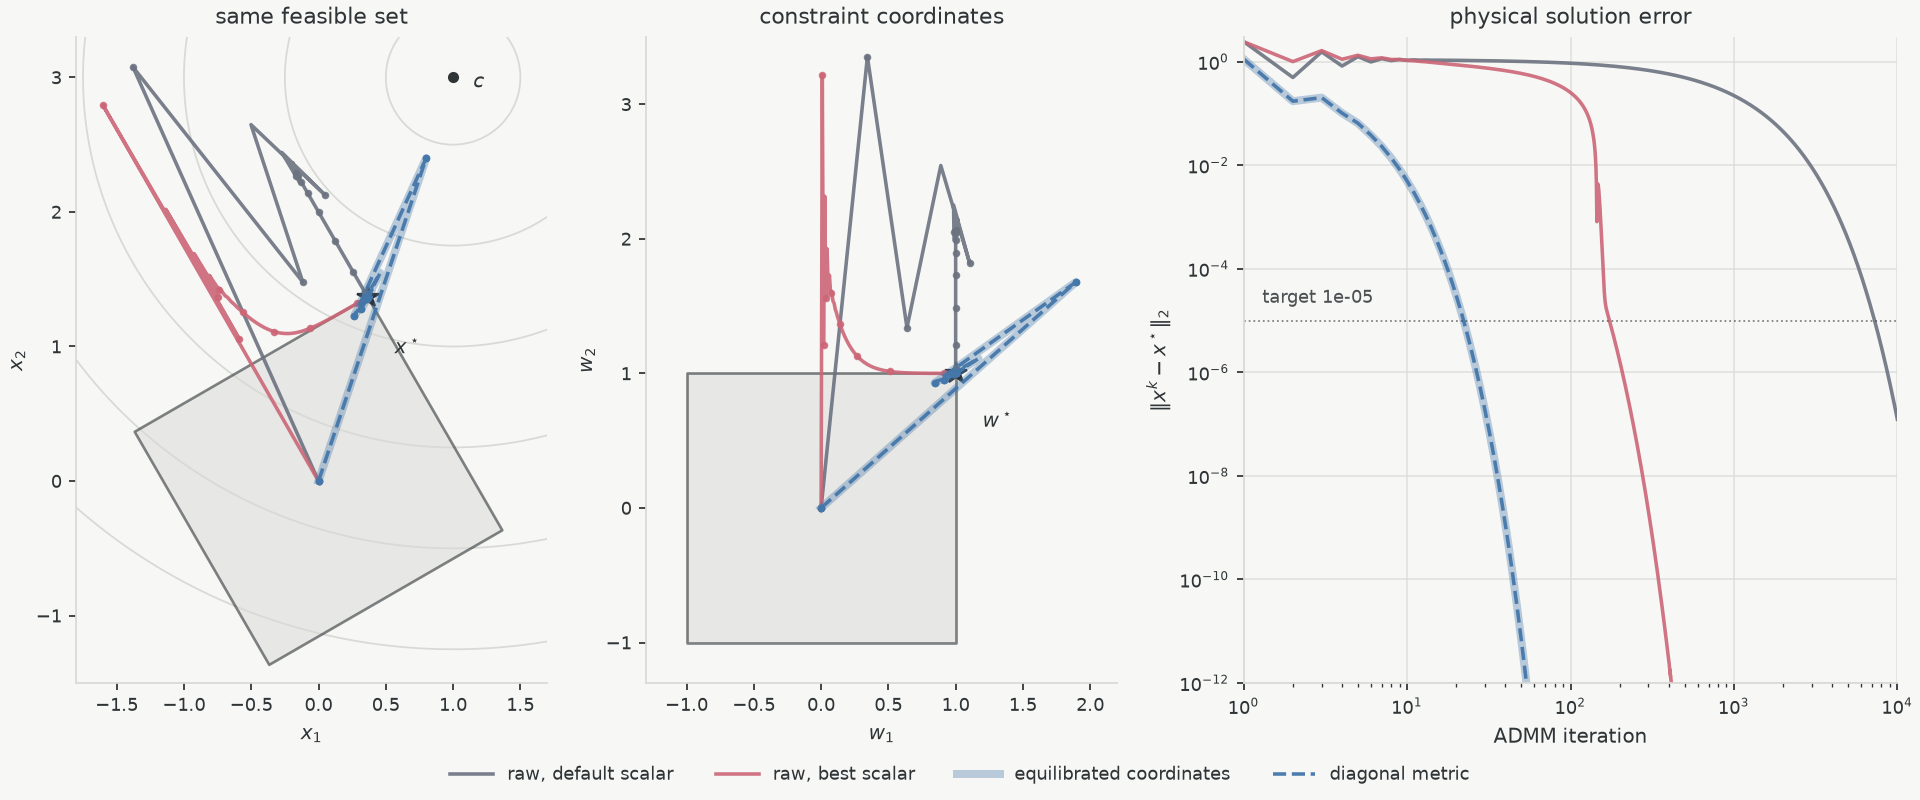

In [14]:
fig, (ax_x, ax_w, ax_e) = plt.subplots(
    1, 3, figsize=(12, 5), dpi=160, layout="constrained", width_ratios=[1, 1, 1.3])

corners = np.array([[1, 1], [1, -1], [-1, -1], [-1, 1], [1, 1]], float)   # the box in w
box_x = corners @ Brot                                     # x = Brot' w, row-stacked

# Panel 1: the physical variables.  Objective contours are circles about c, and the
# rotated square is the one feasible set every run shares.
gx, gy = np.meshgrid(np.linspace(-1.8, 1.7, 241), np.linspace(-1.5, 3.3, 241))
ax_x.contour(gx, gy, 0.5 * ((gx - c[0]) ** 2 + (gy - c[1]) ** 2),
             levels=0.5 * np.arange(0.5, 5.0, 0.75) ** 2,
             colors=GRID, linewidths=0.8)
ax_x.fill(box_x[:, 0], box_x[:, 1], color=GRID, alpha=0.5, lw=0)
ax_x.plot(box_x[:, 0], box_x[:, 1], color=DARK, lw=1.2, alpha=0.6)
ax_x.plot(*c, ls="none", marker="o", ms=4, color=DARK)
ax_x.annotate("$c$", (c[0] + 0.15, c[1] - 0.08), color=DARK)
ax_x.plot(*x_star, ls="none", marker="*", ms=10, color=DARK)
ax_x.annotate("$x^\\star$", (x_star[0] + 0.2, x_star[1] - 0.42), color=DARK)
ax_x.set(xlim=(-1.8, 1.7), ylim=(-1.5, 3.3), xlabel="$x_1$", ylabel="$x_2$",
         title="same feasible set")

# Panel 2: the canonical constraint coordinates w = Brot x, where the feasible set is
# the unit box and the optimum sits in a corner.
ax_w.fill(corners[:, 0], corners[:, 1], color=GRID, alpha=0.5, lw=0)
ax_w.plot(corners[:, 0], corners[:, 1], color=DARK, lw=1.2, alpha=0.6)
ax_w.plot(1, 1, ls="none", marker="*", ms=10, color=DARK)
ax_w.annotate("$w^\\star$", (1.2, 0.6), color=DARK)
ax_w.set(xlim=(-1.3, 2.2), ylim=(-1.3, 3.5), xlabel="$w_1$", ylabel="$w_2$",
         title="constraint coordinates")

for name, xs in runs.items():
    for ax, path in ((ax_x, xs), (ax_w, xs @ Brot.T)):
        ax.plot(path[:, 0], path[:, 1], **STYLE[name])
        ax.plot(path[MARKS, 0], path[MARKS, 1], ls="none", marker="o", ms=2.4,
                color=STYLE[name]["color"], alpha=0.85)

# Panel 3: the representation-invariant error.  Both axes are logarithmic so tens and
# thousands of iterations stay readable on one canvas; curves that reach float64 noise
# leave the frame at the bottom.
k = np.arange(STEPS + 1)
for name, xs in runs.items():
    ax_e.plot(k[1:], solution_error(xs)[1:], label=name, **STYLE[name])
ax_e.axhline(TOL_X, color=DARK, lw=0.8, ls=":", alpha=0.6)
ax_e.annotate(f"target {TOL_X:g}", (1.3, TOL_X * 2.2), color=DARK, fontsize=8, alpha=0.85)
ax_e.set(xscale="log", yscale="log", xlim=(1, STEPS), ylim=(1e-12, 3e0),
         xlabel="ADMM iteration", ylabel="$\\|x^k - x^\\star\\|_2$",
         title="physical solution error")
ax_e.grid(True, color=GRID, lw=0.7, alpha=0.8)

for ax in (ax_x, ax_w):
    ax.set_aspect("equal")
for ax in (ax_x, ax_w, ax_e):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=3, width=0.8, labelsize=8)

fig.legend(*ax_e.get_legend_handles_labels(), loc="outside lower center", ncol=4,
           frameon=False, handlelength=2.4, columnspacing=2.4)

Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/preconditioning.png", dpi=160)
img = plt.imread("assets/preconditioning.png")
print(f"assets/preconditioning.png: {img.shape[1]} x {img.shape[0]} pixels")
assert img.shape[:2] == (800, 1920), img.shape
plt.show()